In [18]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

from tools import scale_out as so
from tools import storage as stor

from emm import data as dat
from emm import fitting
from emm import models
from emm import plotting as plot

figures_cache = stor.ensure_cache("figures")

In [2]:
# Load the data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = dat.get_diphoton_data(tree=True)
diphoton_data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = diphoton_data.numEntries()
data_mean = diphoton_data.mean(x)
print(f"Data mean: {data_mean}")

# Get the binning for the visualization
bins = dat.get_diphoton_binning()

Data mean: 676.7652379849756


In [3]:
fit_options = [
    # ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

In [22]:
# Do model selection
model_primitives = [
    models.ModelPrimitive(
        models.ExponentialMixtureModel,
        k, data_mean=data_mean,
        name=f"ExponentialMixture-{k}"
    ) for k in range(1, 5)
]

results = {}

seed = 42
n_restarts = 20
n_retries = 5

for mp in model_primitives:
    print(f"Fitting {mp.name}...")
    fit_results = fitting.fit_random_restarts(
        x, diphoton_data, mp,
        seed, n_restarts, n_retries,
        save=False, fit_options=fit_options,
        use_multiprocessing=True,
        return_all_results=True
    )
    print(f"   Number of minima found: {len(fit_results)}")
    print(f"   NLLs: {[res['nll'] for res in fit_results]}")

    model = mp(x) # Re-initialize the model to ensure it's in a clean state
    best_result = min(fit_results, key=lambda res: res["nll"])
    model.set_params(best_result["final_pars"])

    aic = 2*len(model.params()) + 2*best_result["nll"]
    bic = len(model.params())*np.log(diphoton_data.numEntries()) + 2*best_result["nll"]
    print(f"   Best fit: nll = {best_result['nll']:.1f}")
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")
    results[model.n_components] = {
        "AIC": aic,
        "BIC": bic,
        "nll": best_result["nll"],
    }


Fitting ExponentialMixture-1...
   Number of minima found: 20
   NLLs: [31096.40617622208, 31096.406182922157, 31096.406176171553, 31096.40629203005, 31096.406181002763, 31096.40617617158, 31096.40617843249, 31096.40617675309, 31096.406176278597, 31096.40618092284, 31096.40619672843, 31096.40627193582, 31096.406181450668, 31096.406177007066, 31096.406178185505, 31096.406177898116, 31096.406176189717, 31096.406207340333, 31096.406176529163, 31096.406176268258]
   Best fit: nll = 31096.4
   AIC: 62196.8, BIC: 62209.9
Fitting ExponentialMixture-2...
   Number of minima found: 20
   NLLs: [31030.831916651845, 31030.83208129828, 31030.831959507104, 31030.83205742534, 31030.831922716705, 31030.832098383387, 31030.83191023905, 31030.83208999694, 31030.83200213846, 31030.831979646267, 31030.832154335407, 31030.83191662058, 31030.83191113815, 31030.831922617937, 31030.832007467172, 31030.83201962653, 31030.833276357556, 31030.831934948408, 31030.831985704113, 31030.831999034188]
   Best fit: nl

Warning in <Minuit2>: DavidonErrorUpdator delgam < 0 : first derivatives increasing along search line (details in info log)
Warning in <Minuit2>: VariableMetricBuilder Matrix not pos.def, gdel = 1418.99 > 0
Warning in <Minuit2>: VariableMetricBuilder gdel = -7.51232e+06
Warning in <Minuit2>: VariableMetricBuilder Reached machine accuracy limit; Edm 0.00125316 is smaller than machine limit 0.00184958 while 0.001 was requested
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00975137
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.028833
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.0167787
Warning in <Minuit2>: Minuit2Minimizer::Minimize Covar was made pos def
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.018084
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.0329453
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 

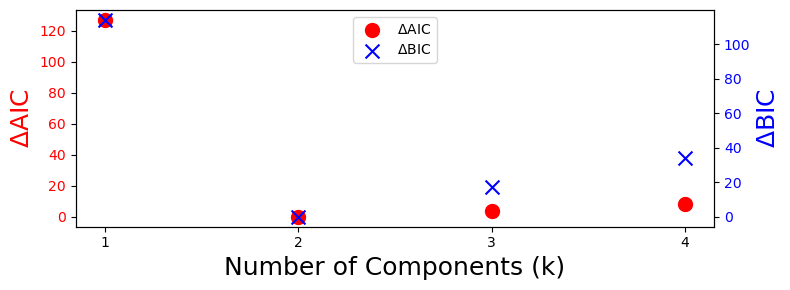

In [ ]:
criteria_by_k = {}
n_observations = diphoton_data.numEntries()
for k, result in results.items():

    criteria_by_k[k] = fitting.compute_information_criteria(
        result["nll"],
        2 * k - 1,
        n_observations,
    )

_ = plot.plot_information_criteria(
    criteria_by_k,
    save_as=f"{figures_cache}/diphoton_model_selection.pdf"
)

In [24]:
# Fit and plot
model_primitives = [
    models.ModelPrimitive(models.f1),
    models.ModelPrimitive(models.f2),
    models.ModelPrimitive(models.f3),
    models.ModelPrimitive(models.f4),
    models.ModelPrimitive(models.ExponentialMixtureModel, 2, data_mean=data_mean, name="ExponentialMixture-2")
]

seed = 42
n_restarts = 20
n_retries = 5

# For visualization and chi2 we bin the data
from array import array
bin_array = array('d', bins)
binning = ROOT.RooBinning(len(bins) - 1, bin_array)
x.setBinning(binning)

# For chi2
hist_name = f"diphoton_binned_data_hist_{ROOT.TUUID().AsString().replace('-', '_')}"
hist = ROOT.TH1D(hist_name, "Binned Data", len(bins) - 1, bin_array)
hist.SetDirectory(0)
diphoton_data.fillHistogram(hist, ROOT.RooArgList(x))

binned_data_name = f"binned_data_{ROOT.TUUID().AsString().replace('-', '_')}"
binned_data = ROOT.RooDataHist(
    binned_data_name,
    "Binned Data",
    ROOT.RooArgList(x),
    hist,
    )

models = []
model_labels = []
model_results = []
for model_primitive in model_primitives:
    print(f"Fitting model: {model_primitive.name}")
    fit_result = fitting.fit_random_restarts(
        x, diphoton_data, model_primitive,
        seed, n_restarts, n_retries,
        save=False,
        fit_options=fit_options,
        use_multiprocessing=True,
        return_all_results=False
        )


    model = model_primitive(x) # Re-initialize the model to ensure it's in a clean state
    model.set_params(fit_result["final_pars"])
    if "ExponentialMixture" in model.name:
        k = model.name.split("-")[-1]
        model_label = f"Exponential Mixture"
    else:
        model_func = model.name.split("_")[0]
        model_num = model.name.split("_")[-1]
        model_label = f"#it{{f}}_{{{model_num}}}"

    nll = fit_result["nll"]
    n = diphoton_data.numEntries()
    k = len(model.params())
    aic = 2*k + 2*nll
    bic = k*np.log(n) + 2*nll
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")

    chi2_res = fitting.chi2(
        x,
        hist,
        model,
        min_events=30,
        print_chi2=True,
        )
    
    models.append(model)
    model_labels.append(model_label)
    model_results.append({
        "model": model,
        "label": model_label,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "chi2": chi2_res["chi2"],
        "chi2_ndf": chi2_res["chi2_ndf"],
    })

Fitting model: f_1
   AIC: 62070.0, BIC: 62083.1
chi2=54.18, ndf=58, chi2/ndf=0.934, 
Fitting model: f_2
   AIC: 62068.5, BIC: 62081.5
chi2=53.48, ndf=58, chi2/ndf=0.922, 
Fitting model: f_3
   AIC: 62071.0, BIC: 62084.0
chi2=54.69, ndf=58, chi2/ndf=0.943, 
Fitting model: f_4
   AIC: 62070.3, BIC: 62089.9
chi2=53.40, ndf=57, chi2/ndf=0.937, 
Fitting model: ExponentialMixture-2
   AIC: 62069.7, BIC: 62095.8
chi2=50.58, ndf=56, chi2/ndf=0.903, 
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator [#1] [#[#INFO:1] INFO1:] INFO:NumericIntegration -- RooRealIntegral::init(NumericIntegrationNumericIntegration -- RooRealIntegral::init(f_1_Int[x]f_1_Int[x]) using numeric integrator ) using numeric integrator  -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegratorRooRombergIntegrator to calculate Int to calculate Int((x)x
)
RooRombergIntegratorRooRombergIntegrator to calculate Int to calculate Int((xx))

[#1[#] INFO1:] Minimizati

Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00456857
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.0125191
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00557152
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00487698
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00471895
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00485753
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00453968
Warning in <Minuit2>: Minuit2Minimizer::Minimize Covar was made pos def
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00448574
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00444501
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00224597
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to dia

[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_4_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)


Info in <TCanvas::Print>: png file /project01/ndcms/atownse2/ExponentialMixtureModel/cache/figures/diphoton_fit.png has been created


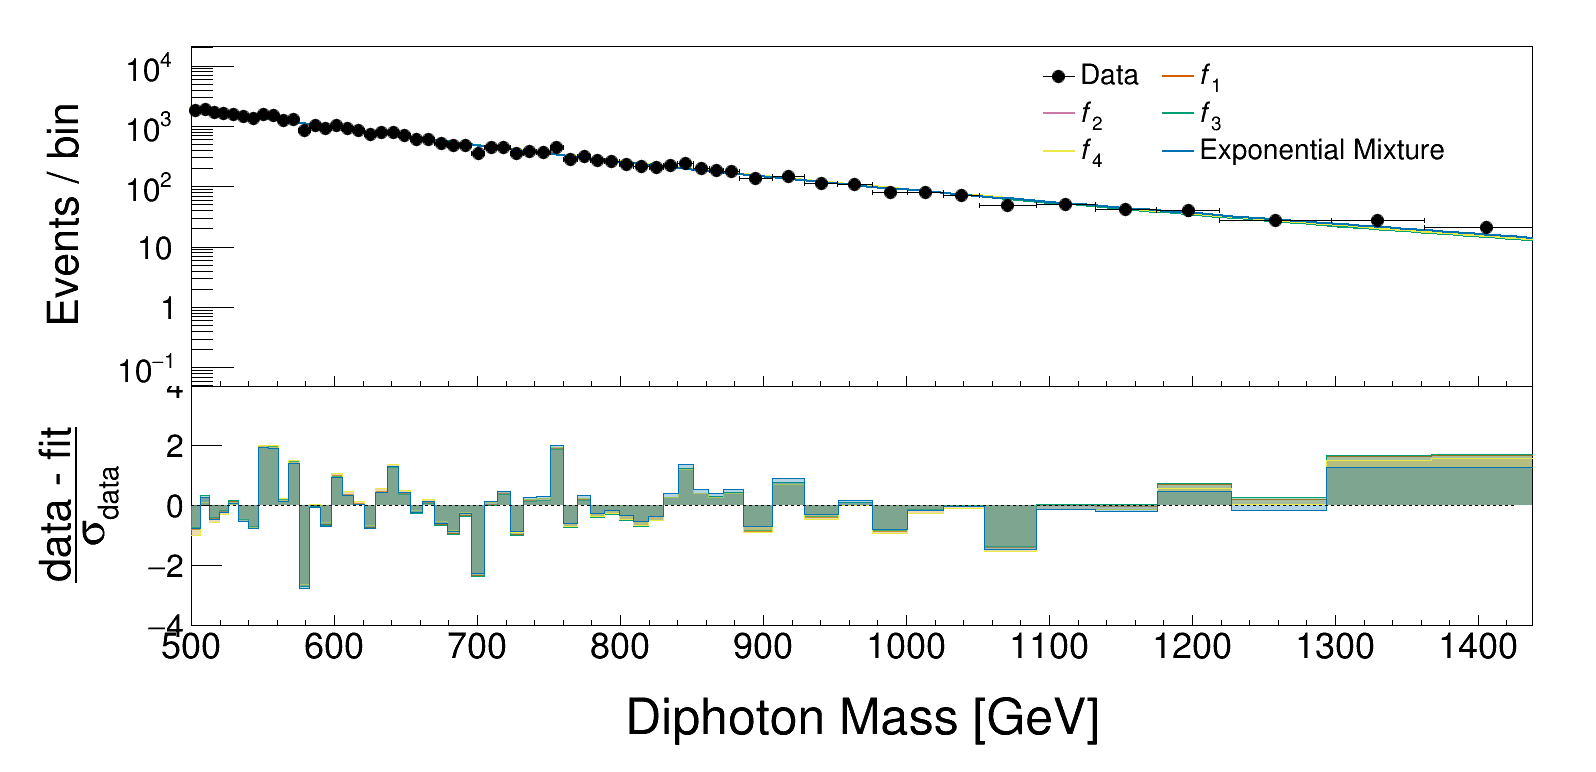

In [28]:
_ = plot.plot_fits(
    diphoton_data, x, models,
    labels=model_labels,
    # title="CMS High Mass Diphoton Spectrum",
    # colors=[ROOT.kRed],
    plot_range=(500, 1425),
    # nbins=128,
    y_min=5e-2,
    # logx=True,
    legend_bounds=(0.65, 0.56, 0.95, 0.85),
    legend_text_size=0.08,
    legend_columns=2,
    pull_fill_alpha=0.3,
    save_as=f"{figures_cache}/diphoton_fit.png"
    )

In [ ]:
# Format results into a latex table
print("\n\nLaTeX Table:")
print("\\begin{tabular}{lcccc}")
print("Model & $\\chi^2$ & $\\chi^2_\\nu$ & $\Delta$AIC & $\Delta$BIC \\\\")
aic_min = min(res["aic"] for res in model_results)
bic_min = min(res["bic"] for res in model_results)
print("\\hline")
for res in model_results:
    delta_aic = res["aic"] - aic_min
    delta_bic = res["bic"] - bic_min
    label = res['label'].replace('#it{', '').replace('}', '').replace('{', '')
    if "Exponential Mixture" in label:
        label = "Exponential Mixture"
    else:
        label = f"${label}$"
    print(f"{label} & {res['chi2']:.1f} & {res['chi2_ndf']:.2f} & {delta_aic:.1f} & {delta_bic:.1f} \\\\")
print("\\end{tabular}")

In [ ]:
hist_name = f"diphoton_binned_data_hist_{ROOT.TUUID().AsString().replace('-', '_')}"
hist = ROOT.TH1D(hist_name, "Binned Data", len(bins) - 1, bin_array)
hist.SetDirectory(0)
data.fillHistogram(hist, ROOT.RooArgList(x))

binned_data_name = f"binned_data_{ROOT.TUUID().AsString().replace('-', '_')}"
binned_data = ROOT.RooDataHist(
    binned_data_name,
    "Binned Data",
    ROOT.RooArgList(x),
    hist,
    )
print(f"Number of bins in binned data: {binned_data.numEntries()}")

for model in models:
    print(f"Evaluating model: {model.name}")
    emm.chi2(
        x,
        hist,
        model,
        min_events=30,
        print_chi2=True,
        )